In [1]:
#### conda env Weather_Prediction

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error


import shap
import os
import geopandas as gpd
pd.set_option('display.precision', 15)
pd.set_option('display.max_columns', None)

In [2]:
df1=pd.read_pickle('final_dataset_103_features_90th_percentile.pkl')
full_df = df1.drop(['fips', 'year'], axis=1)
full_df

,MeanLifeExpectency,2m dew point temperature,2m temperature,Black carbon AOD at 550 nm,Dust AOD at 550 nm,Land-sea mask,Mean sea level pressure,Organic matter AOD at 550 nm,PM$_1$,PM$_{2.5}$,PM$_{10}$,Sea salt AOD at 550 nm,Sulphate AOD at 550 nm,Surface geopotential,Surface pressure,Total AOD at 469 nm,Total AOD at 550 nm,Total AOD at 670 nm,Total AOD at 865 nm,Total AOD at 1240 nm,Total column carbon monoxide,Total column ethane,Total column formaldehyde,Total column hydrogen peroxide,Total column hydroxyl radical,Total column isoprene,Total column methane,Total column nitric acid,Total column nitrogen dioxide,Total column nitrogen monoxide,Total column ozone,Total column peroxyacetyl nitrate,Total column propane,Total column sulphur dioxide,Total column water vapour,Carbon monoxide,Dust aerosol (0.03-0.55 µm) mixing ratio,Dust aerosol (0.55-0.9 µm) mixing ratio,Dust aerosol (0.9-20 µm) mixing ratio,Ethane,Formaldehyde,Hydrogen peroxide,Hydrophilic black carbon aerosol mixing ratio,Hydrophilic organic matter aerosol mixing ratio,Hydrophobic black carbon aerosol mixing ratio,Hydrophobic organic matter aerosol mixing ratio,Hydroxyl radical,Isoprene,Nitric acid,Nitrogen dioxide,Nitrogen monoxide,Ozone,Peroxyacetyl nitrate,Propane,Sea salt aerosol (0.03-0.5 µm) mixing ratio,Sea salt aerosol (0.5-5 µm) mixing ratio,Sea salt aerosol (5-20 µm) mixing ratio,Specific humidity,Sulphate aerosol mixing ratio,Sulphur dioxide,Temperature,"Leaf area index, high vegetation","Leaf area index, low vegetation",Snow albedo,Snow depth,Total column water,Vertically integrated mass of dust aerosol (0.03-0.55 µm),Vertically integrated mass of dust aerosol (0.55-9 µm),Vertically integrated mass of dust aerosol (9-20 µm),Vertically integrated mass of hydrophilic black carbon aerosol,Vertically integrated mass of hydrophilic organic matter aerosol,Vertically integrated mass of hydrophobic black carbon aerosol,Vertically integrated mass of hydrophobic organic matter aerosol,Vertically integrated mass of sea salt aerosol (0.03-0.5 µm),Vertically integrated mass of sea salt aerosol (0.5-5 µm),Vertically integrated mass of sea salt aerosol (5-20 µm),Vertically integrated mass of sulphate aerosol,Vertically integrated mass of sulphur dioxide,Relative humidity,10m wind speed,Wet bulb temperature,FoT Carbonmonoxide above 90ᵗʰ percentile,FoT Ethane above 90ᵗʰ percentile,FoT Formaldehyde above 90ᵗʰ percentile,FoT Hydroxyl radical above 90ᵗʰ percentile,FoT Isoprene above 90ᵗʰ percentile,FoT Peroxyacetyl Nitrate above 90ᵗʰ percentile,FoT Nitric acid above 90ᵗʰ percentile,FoT Nitrogen dioxide above 90ᵗʰ percentile,FoT Nitrogen monoxide above 90ᵗʰ percentile,FoT Ozone above 90ᵗʰ percentile,FoT Hydrogen peroxide above 90ᵗʰ percentile,FoT PM$_{10}$ above 90ᵗʰ percentile,FoT PM$_{1}$ above 90ᵗʰ percentile,FoT PM$_{2.5}$ above 90ᵗʰ percentile,FoT Propane above 90ᵗʰ percentile,FoT Sulphur dioxide above 90ᵗʰ percentile,FoT Temperature above 90ᵗʰ percentile,FoT Temperature below 10ᵗʰ percentile,FoT PM$_{10}$ above EPA threshold,FoT Temperature above 90 $\mathrm{^o F}$,FoT Temperature below 0 $\mathrm{^o C}$,FoT PM$_{2.5}$ above EPA threshold
0,74.628765329999993,285.629269414872169,290.863352214209158,0.00757124815486,0.010371692890225,0.986464531564209,101746.46078524258337,0.097522246908886,0.000000015615338,0.000000019601377,0.000000027192044,0.00860619294015,0.112170314070482,1368.670051439976305,100086.817007783130975,0.288798537560071,0.236241944078782,0.180380990078313,0.123618863685572,0.069164993038643,0.000984550381998,0.000003862356441,0.000003599970514,0.000008836077454,0.000000004853489,0.000001984446001,0.009753834615672,0.000007246513254,0.000004130302193,0.000000542480041,0.006426156201957,0.000008713431766,0.00000074020297,0.000004737026637,25.902900677695214,0.000000230284119,0.000000000654884,0.000000001134462,0.000000000403961,0.000000000705993,0.000000003513651,0.000000000741261,0.00000000022451,0.000000010096395,0.000000000254529,0.000000005847693,0

In [3]:
columns_to_remove = ['Land-sea mask', 'Total AOD at 550 nm','Total AOD at 670 nm','Total AOD at 865 nm',
                      'Dust aerosol (0.55-0.9 \u00B5m) mixing ratio','Dust aerosol (0.9-20 \u00B5m) mixing ratio',
                    'Hydrophilic black carbon aerosol mixing ratio','Hydrophilic organic matter aerosol mixing ratio',
                     'Hydrophobic black carbon aerosol mixing ratio','Hydrophobic organic matter aerosol mixing ratio',
                    'Sea salt aerosol (0.03-0.5 \u00B5m) mixing ratio','Sea salt aerosol (0.5-5 \u00B5m) mixing ratio',
                     'Sea salt aerosol (5-20 \u00B5m) mixing ratio',
                     'FoT Propane above 90ᵗʰ percentile',
                     'FoT Nitric acid above 90ᵗʰ percentile',
                     'FoT Ethane above 90ᵗʰ percentile',                     
                     'Vertically integrated mass of dust aerosol (0.55-9 \u00B5m)',
                      'Vertically integrated mass of dust aerosol (9-20 \u00B5m)',
                     'Vertically integrated mass of hydrophilic black carbon aerosol',
                    'Vertically integrated mass of hydrophilic black carbon aerosol',
                     'Vertically integrated mass of hydrophilic organic matter aerosol',
                     'Vertically integrated mass of hydrophobic black carbon aerosol',
                     'Vertically integrated mass of hydrophobic organic matter aerosol',
                    'Vertically integrated mass of sea salt aerosol (0.5-5 \u00B5m)',
                     'Vertically integrated mass of sea salt aerosol (5-20 \u00B5m)' ]

In [4]:
full_df = full_df.drop(columns=columns_to_remove)
full_df

,MeanLifeExpectency,2m dew point temperature,2m temperature,Black carbon AOD at 550 nm,Dust AOD at 550 nm,Mean sea level pressure,Organic matter AOD at 550 nm,PM$_1$,PM$_{2.5}$,PM$_{10}$,Sea salt AOD at 550 nm,Sulphate AOD at 550 nm,Surface geopotential,Surface pressure,Total AOD at 469 nm,Total AOD at 1240 nm,Total column carbon monoxide,Total column ethane,Total column formaldehyde,Total column hydrogen peroxide,Total column hydroxyl radical,Total column isoprene,Total column methane,Total column nitric acid,Total column nitrogen dioxide,Total column nitrogen monoxide,Total column ozone,Total column peroxyacetyl nitrate,Total column propane,Total column sulphur dioxide,Total column water vapour,Carbon monoxide,Dust aerosol (0.03-0.55 µm) mixing ratio,Ethane,Formaldehyde,Hydrogen peroxide,Hydroxyl radical,Isoprene,Nitric acid,Nitrogen dioxide,Nitrogen monoxide,Ozone,Peroxyacetyl nitrate,Propane,Specific humidity,Sulphate aerosol mixing ratio,Sulphur dioxide,Temperature,"Leaf area index, high vegetation","Leaf area index, low vegetation",Snow albedo,Snow depth,Total column water,Vertically integrated mass of dust aerosol (0.03-0.55 µm),Vertically integrated mass of sea salt aerosol (0.03-0.5 µm),Vertically integrated mass of sulphate aerosol,Vertically integrated mass of sulphur dioxide,Relative humidity,10m wind speed,Wet bulb temperature,FoT Carbonmonoxide above 90ᵗʰ percentile,FoT Formaldehyde above 90ᵗʰ percentile,FoT Hydroxyl radical above 90ᵗʰ percentile,FoT Isoprene above 90ᵗʰ percentile,FoT Peroxyacetyl Nitrate above 90ᵗʰ percentile,FoT Nitrogen dioxide above 90ᵗʰ percentile,FoT Nitrogen monoxide above 90ᵗʰ percentile,FoT Ozone above 90ᵗʰ percentile,FoT Hydrogen peroxide above 90ᵗʰ percentile,FoT PM$_{10}$ above 90ᵗʰ percentile,FoT PM$_{1}$ above 90ᵗʰ percentile,FoT PM$_{2.5}$ above 90ᵗʰ percentile,FoT Sulphur dioxide above 90ᵗʰ percentile,FoT Temperature above 90ᵗʰ percentile,FoT Temperature below 10ᵗʰ percentile,FoT PM$_{10}$ above EPA threshold,FoT Temperature above 90 $\mathrm{^o F}$,FoT Temperature below 0 $\mathrm{^o C}$,FoT PM$_{2.5}$ above EPA threshold
0,74.628765329999993,285.629269414872169,290.863352214209158,0.00757124815486,0.010371692890225,101746.46078524258337,0.097522246908886,0.000000015615338,0.000000019601377,0.000000027192044,0.00860619294015,0.112170314070482,1368.670051439976305,100086.817007783130975,0.288798537560071,0.069164993038643,0.000984550381998,0.000003862356441,0.000003599970514,0.000008836077454,0.000000004853489,0.000001984446001,0.009753834615672,0.000007246513254,0.000004130302193,0.000000542480041,0.006426156201957,0.000008713431766,0.00000074020297,0.000004737026637,25.902900677695214,0.000000230284119,0.000000000654884,0.000000000705993,0.000000003513651,0.000000000741261,0.000000000000028,0.000000014604292,0.000000001474772,0.000000010235872,0.000000000867748,0.00000005814554,0.000000003056157,0.000000000328437,0.010010040534155,0.00000000404404,0.000000009229008,17.605204629052423,3.904460199286052,2.618741604547198,0.879750469058084,0.000000093784908,26.035876613510123,0.000001993471045,0.000000220848889,0.000011681476149,0.00000288632888,71.152047054515833,0.209342152896552,14.185547266162992,19.623287671232877,46.643835616438359,22.979452054794521,33.082191780821915,42.328767123287669,13.493150684931507,3.869863013698630,45.376712328767120,28.904109589041095,29.383561643835616,22.157534246575342,30.753424657534246,16.780821917808218,52.363013698630134,13.116438356164384,0.034246575342466,0.000000000000000,1.643835616438356,78.219178082191775
1,76.661419230000007,289.075082204243699,292.904504754344714,0.007386436848696,0.012786048677104,101714.38567138351209,0.080536809563287,0.000000010517524,0.000000014405518,0.000000020184934,0.013378239581773,0.098994377620422,170.454787516937728,101507.029992429539561,0.25854819556795,0.068677769359272,0.000938742452444,0.000003715951851,0.000002695483373,0.000009696511809,0.000000004901349,0.000000603500308,0.009897973997385,0.000006

In [5]:
## remove further total column variables

new_columns_to_remove = ['Black carbon AOD at 550 nm', 'Dust AOD at 550 nm','Organic matter AOD at 550 nm',
                     'Sea salt AOD at 550 nm','Sulphate AOD at 550 nm','Total AOD at 469 nm','Total AOD at 1240 nm',
                    'Total column carbon monoxide','Total column ethane','Total column formaldehyde','Total column hydrogen peroxide',
                    'Total column hydroxyl radical','Total column isoprene','Total column methane','Total column nitric acid',
                    'Total column nitrogen dioxide','Total column nitrogen monoxide','Total column peroxyacetyl nitrate',
                    'Total column propane',
                    'Total column sulphur dioxide','Total column water vapour','Total column water',
                    'Vertically integrated mass of dust aerosol (0.03-0.55 µm)',
                    'Vertically integrated mass of sea salt aerosol (0.03-0.5 µm)',
                    'Vertically integrated mass of sulphate aerosol','Vertically integrated mass of sulphur dioxide',
                    'FoT Carbonmonoxide above 90ᵗʰ percentile','FoT Nitrogen dioxide above 90ᵗʰ percentile',
                     'FoT Nitrogen monoxide above 90ᵗʰ percentile','FoT PM$_{10}$ above 90ᵗʰ percentile',
                      'FoT PM$_{2.5}$ above 90ᵗʰ percentile','FoT PM$_{1}$ above 90ᵗʰ percentile',
                        'FoT Sulphur dioxide above 90ᵗʰ percentile']

In [6]:
full_df = full_df.drop(columns=new_columns_to_remove)
full_df

,MeanLifeExpectency,2m dew point temperature,2m temperature,Mean sea level pressure,PM$_1$,PM$_{2.5}$,PM$_{10}$,Surface geopotential,Surface pressure,Total column ozone,Carbon monoxide,Dust aerosol (0.03-0.55 µm) mixing ratio,Ethane,Formaldehyde,Hydrogen peroxide,Hydroxyl radical,Isoprene,Nitric acid,Nitrogen dioxide,Nitrogen monoxide,Ozone,Peroxyacetyl nitrate,Propane,Specific humidity,Sulphate aerosol mixing ratio,Sulphur dioxide,Temperature,"Leaf area index, high vegetation","Leaf area index, low vegetation",Snow albedo,Snow depth,Relative humidity,10m wind speed,Wet bulb temperature,FoT Formaldehyde above 90ᵗʰ percentile,FoT Hydroxyl radical above 90ᵗʰ percentile,FoT Isoprene above 90ᵗʰ percentile,FoT Peroxyacetyl Nitrate above 90ᵗʰ percentile,FoT Ozone above 90ᵗʰ percentile,FoT Hydrogen peroxide above 90ᵗʰ percentile,FoT Temperature above 90ᵗʰ percentile,FoT Temperature below 10ᵗʰ percentile,FoT PM$_{10}$ above EPA threshold,FoT Temperature above 90 $\mathrm{^o F}$,FoT Temperature below 0 $\mathrm{^o C}$,FoT PM$_{2.5}$ above EPA threshold
0,74.628765329999993,285.629269414872169,290.863352214209158,101746.46078524258337,0.000000015615338,0.000000019601377,0.000000027192044,1368.670051439976305,100086.817007783130975,0.006426156201957,0.000000230284119,0.000000000654884,0.000000000705993,0.000000003513651,0.000000000741261,0.000000000000028,0.000000014604292,0.000000001474772,0.000000010235872,0.000000000867748,0.00000005814554,0.000000003056157,0.000000000328437,0.010010040534155,0.00000000404404,0.000000009229008,17.605204629052423,3.904460199286052,2.618741604547198,0.879750469058084,0.000000093784908,71.152047054515833,0.209342152896552,14.185547266162992,46.643835616438359,22.979452054794521,33.082191780821915,42.328767123287669,45.376712328767120,28.904109589041095,52.363013698630134,13.116438356164384,0.034246575342466,0.000000000000000,1.643835616438356,78.219178082191775
1,76.661419230000007,289.075082204243699,292.904504754344714,101714.38567138351209,0.000000010517524,0.000000014405518,0.000000020184934,170.454787516937728,101507.029992429539561,0.006262634883947,0.000000181097315,0.000000000693319,0.000000000603835,0.000000001813065,0.000000000839633,0.000000000000043,0.000000003807398,0.000000001664988,0.000000006039749,0.000000000390859,0.000000063545074,0.000000001913777,0.000000000255961,0.012053964031284,0.000000003376943,0.000000004951391,19.898584096705463,2.493748263318578,1.556460793604144,0.87998489125148,0.0,74.39917284407359,0.42506917399947,16.735605496466448,18.767123287671232,29.143835616438356,6.952054794520548,22.089041095890412,56.506849315068500,44.897260273972599,60.958904109589042,3.287671232876712,0.000000000000000,0.000000000000000,0.136986301369863,70.000000000000000
2,74.047810630000001,285.84173359686946,291.336096185519921,101751.023443022204447,0.000000014401388,0.000000018304776,0.000000025313996,1263.685437879796154,100218.776953070439049,0.006383518344924,0.000000225396546,0.000000000696949,0.000000000685152,0.000000003130391,0.000000000760942,0.000000000000028,0.000000013132761,0.000000001363316,0.00000000807493,0.000000000588739,0.000000055329099,0.000000002668089,0.000000000302966,0.010116411670589,0.000000003173645,0.000000003391913,18.094292469938807,4.174570187840095,2.367511530630567,0.879915804230056,0.0,71.229239958483802,0.169872508900564,14.652120108679608,44.315068493150683,23.493150684931507,31.712328767123289,37.568493150684937,42.397260273972606,30.171232876712327,53.801369863013704,11.267123287671232,0.136986301369863,0.068493150684932,1.232876712328767,76.369863013698634
3,73.057987400000002,285.117221444791198,290.369989746752196,101744.124161676227232,0.000000016317548,0.000000020307433,0.000000028238688,1465.598787847873382,99965.021140069555258,0.006478358100203,0.000000235334185,0.0000000006092,0.00000000072361,0.000000003373964,0.000000000699918,0.000000000000028,0.000000013479486,0.00000000160143,0.000000013131751,0.000000001689682,0.000000056414364,0.00000

# Get rid of multicollinearity

In [7]:
X=full_df.drop('MeanLifeExpectency',axis=1)

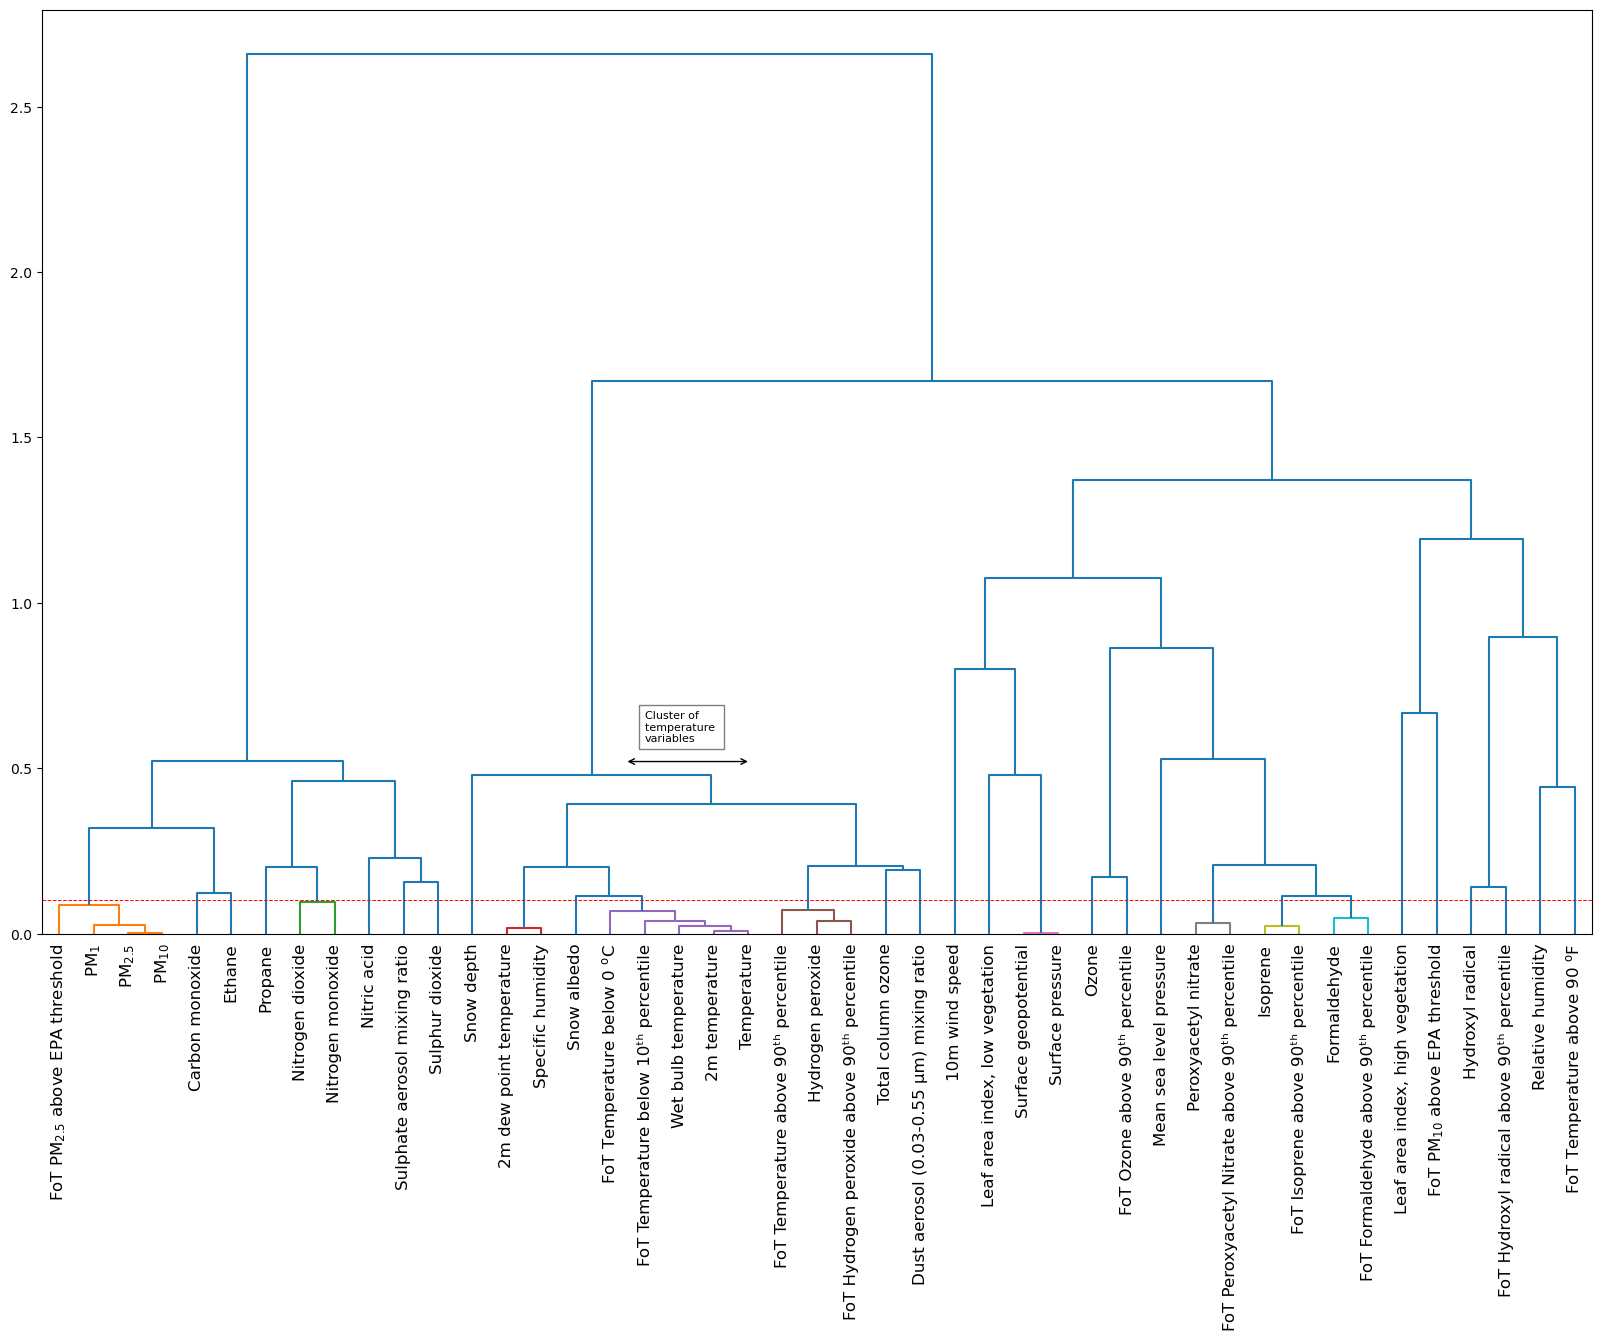

In [8]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
fig, ax = plt.subplots(figsize=(20,12))

corr = spearmanr(X).correlation

# Ensure the correlation matrix is symmetric
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

# We convert the correlation matrix to a distance matrix before performing
# hierarchical clustering using Ward's linkage.
distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))
dendro = hierarchy.dendrogram(
    dist_linkage, labels=X.columns.to_list(), ax=ax, leaf_rotation=90, color_threshold=0.10
)
dendro_idx = np.arange(0, len(dendro["ivl"]))
plt.axhline(y=0.10, color='r', linestyle='--', label='Threshold at y=0.10', linewidth=0.7)

plt.xticks(fontsize=12) 
## create double arrow to annotate temperature cluster
plt.annotate(
    '',
    xy = (170, 0.52), # End point of the arrow
    xytext = (205, 0.52), # Start point of the arrow
    arrowprops = dict(
        arrowstyle = '<->',
        color = 'black',
        lw = 1,
        shrinkA = 0, # Prevents arrow from shrinking from start
        shrinkB = 0, # Prevents arrow from shrinking from end
    )
)

# Add a text box to the plot
plt.text(175, 0.58, 'Cluster of \ntemperature \nvariables', fontsize=8,
         bbox=dict(facecolor='white', alpha=0.5))
plt.savefig('dendrogram', bbox_inches='tight')

In [9]:
from collections import defaultdict

cluster_ids = hierarchy.fcluster(dist_linkage, 0.10, criterion="distance")
cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
    cluster_id_to_feature_ids[cluster_id].append(idx)
selected_features = [v[0] for v in cluster_id_to_feature_ids.values()]
selected_features_names = X.columns[selected_features]
selected_features_names

Index(['2m dew point temperature', '2m temperature', 'Mean sea level pressure',
       'PM$_1$', 'Surface geopotential', 'Total column ozone',
       'Carbon monoxide', 'Dust aerosol (0.03-0.55 µm) mixing ratio', 'Ethane',
       'Formaldehyde', 'Hydrogen peroxide', 'Hydroxyl radical', 'Isoprene',
       'Nitric acid', 'Nitrogen dioxide', 'Ozone', 'Peroxyacetyl nitrate',
       'Propane', 'Sulphate aerosol mixing ratio', 'Sulphur dioxide',
       'Leaf area index, high vegetation', 'Leaf area index, low vegetation',
       'Snow albedo', 'Snow depth', 'Relative humidity', '10m wind speed',
       'FoT Hydroxyl radical above 90ᵗʰ percentile',
       'FoT Ozone above 90ᵗʰ percentile', 'FoT PM$_{10}$ above EPA threshold',
       'FoT Temperature above 90 $\mathrm{^o F}$'],
      dtype='object')

In [10]:
new_features = selected_features_names.to_list()

In [11]:
new_features.append('MeanLifeExpectency')
new_features

['2m dew point temperature',
 '2m temperature',
 'Mean sea level pressure',
 'PM$_1$',
 'Surface geopotential',
 'Total column ozone',
 'Carbon monoxide',
 'Dust aerosol (0.03-0.55 µm) mixing ratio',
 'Ethane',
 'Formaldehyde',
 'Hydrogen peroxide',
 'Hydroxyl radical',
 'Isoprene',
 'Nitric acid',
 'Nitrogen dioxide',
 'Ozone',
 'Peroxyacetyl nitrate',
 'Propane',
 'Sulphate aerosol mixing ratio',
 'Sulphur dioxide',
 'Leaf area index, high vegetation',
 'Leaf area index, low vegetation',
 'Snow albedo',
 'Snow depth',
 'Relative humidity',
 '10m wind speed',
 'FoT Hydroxyl radical above 90ᵗʰ percentile',
 'FoT Ozone above 90ᵗʰ percentile',
 'FoT PM$_{10}$ above EPA threshold',
 'FoT Temperature above 90 $\\mathrm{^o F}$',
 'MeanLifeExpectency']

In [12]:
len(new_features)

31

In [13]:
## select features that are easy to interpret from a cluster of features

remove= [   "PM$_1$",                              ## replace by PM$_{2.5}$    
            "2m dew point temperature",            ## replace by Specific Humidity        
            "Surface geopotential" ,               ## replace by surface pressure           
            "2m temperature",                      ## replace by Wetbulb temperature                                 
        ]

new_list=[]                             ## remove the features in above list
for i in new_features:
    if i not in remove:
        new_list.append(i)

## add these features

added_features=['Specific humidity','Surface pressure','Wet bulb temperature','PM$_{2.5}$' ]
for item in added_features:
    new_list.append(item)

In [14]:
new_features = new_list

In [15]:
new_features

['Mean sea level pressure',
 'Total column ozone',
 'Carbon monoxide',
 'Dust aerosol (0.03-0.55 µm) mixing ratio',
 'Ethane',
 'Formaldehyde',
 'Hydrogen peroxide',
 'Hydroxyl radical',
 'Isoprene',
 'Nitric acid',
 'Nitrogen dioxide',
 'Ozone',
 'Peroxyacetyl nitrate',
 'Propane',
 'Sulphate aerosol mixing ratio',
 'Sulphur dioxide',
 'Leaf area index, high vegetation',
 'Leaf area index, low vegetation',
 'Snow albedo',
 'Snow depth',
 'Relative humidity',
 '10m wind speed',
 'FoT Hydroxyl radical above 90ᵗʰ percentile',
 'FoT Ozone above 90ᵗʰ percentile',
 'FoT PM$_{10}$ above EPA threshold',
 'FoT Temperature above 90 $\\mathrm{^o F}$',
 'MeanLifeExpectency',
 'Specific humidity',
 'Surface pressure',
 'Wet bulb temperature',
 'PM$_{2.5}$']

# Estimate by getting rid of collinear features

In [16]:
full_df = full_df.loc[:, new_features]
full_df

,Mean sea level pressure,Total column ozone,Carbon monoxide,Dust aerosol (0.03-0.55 µm) mixing ratio,Ethane,Formaldehyde,Hydrogen peroxide,Hydroxyl radical,Isoprene,Nitric acid,Nitrogen dioxide,Ozone,Peroxyacetyl nitrate,Propane,Sulphate aerosol mixing ratio,Sulphur dioxide,"Leaf area index, high vegetation","Leaf area index, low vegetation",Snow albedo,Snow depth,Relative humidity,10m wind speed,FoT Hydroxyl radical above 90ᵗʰ percentile,FoT Ozone above 90ᵗʰ percentile,FoT PM$_{10}$ above EPA threshold,FoT Temperature above 90 $\mathrm{^o F}$,MeanLifeExpectency,Specific humidity,Surface pressure,Wet bulb temperature,PM$_{2.5}$
0,101746.46078524258337,0.006426156201957,0.000000230284119,0.000000000654884,0.000000000705993,0.000000003513651,0.000000000741261,0.000000000000028,0.000000014604292,0.000000001474772,0.000000010235872,0.00000005814554,0.000000003056157,0.000000000328437,0.00000000404404,0.000000009229008,3.904460199286052,2.618741604547198,0.879750469058084,0.000000093784908,71.152047054515833,0.209342152896552,22.979452054794521,45.376712328767120,0.034246575342466,0.000000000000000,74.628765329999993,0.010010040534155,100086.817007783130975,14.185547266162992,0.000000019601377
1,101714.38567138351209,0.006262634883947,0.000000181097315,0.000000000693319,0.000000000603835,0.000000001813065,0.000000000839633,0.000000000000043,0.000000003807398,0.000000001664988,0.000000006039749,0.000000063545074,0.000000001913777,0.000000000255961,0.000000003376943,0.000000004951391,2.493748263318578,1.556460793604144,0.87998489125148,0.0,74.39917284407359,0.42506917399947,29.143835616438356,56.506849315068500,0.000000000000000,0.000000000000000,76.661419230000007,0.012053964031284,101507.029992429539561,16.735605496466448,0.000000014405518
2,101751.023443022204447,0.006383518344924,0.000000225396546,0.000000000696949,0.000000000685152,0.000000003130391,0.000000000760942,0.000000000000028,0.000000013132761,0.000000001363316,0.00000000807493,0.000000055329099,0.000000002668089,0.000000000302966,0.000000003173645,0.000000003391913,4.174570187840095,2.367511530630567,0.879915804230056,0.0,71.229239958483802,0.169872508900564,23.493150684931507,42.397260273972606,0.136986301369863,0.068493150684932,74.047810630000001,0.010116411670589,100218.776953070439049,14.652120108679608,0.000000018304776
3,101744.124161676227232,0.006478358100203,0.000000235334185,0.0000000006092,0.00000000072361,0.000000003373964,0.000000000699918,0.000000000000028,0.000000013479486,0.00000000160143,0.000000013131751,0.000000056414364,0.000000003056251,0.000000000358899,0.000000004729935,0.000000013603814,3.638957935933739,2.754823872966046,0.878014749774689,0.000011574283667,72.651517962262062,0.247677504482458,21.712328767123289,42.260273972602739,0.205479452054795,0.000000000000000,73.057987400000002,0.009712725129444,99965.021140069555258,13.829282111100266,0.000000020307433
4,101752.892546598464833,0.006526528523785,0.000000243128079,0.000000000565979,0.000000000742636,0.000000002956875,0.000000000648027,0.000000000000031,0.000000010923979,0.000000001704878,0.000000014273459,0.000000055735722,0.000000002906905,0.000000000399657,0.000000004897891,0.000000013819481,3.286418753252266,2.78269651469914,0.874594005175991,0.000146268439547,73.001927053727783,0.313663384140064,21.883561643835616,41.198630136986303,0.102739726027397,0.000000000000000,75.053119350000003,0.009374448422807,99291.479349611210637,13.082501247882803,0.000000020577427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52315,101728.279968551723869,0.006791831263302,0.000000135233435,0.000000000301368,0.000000000413873,0.000000000717546,0.000000000341813,0.000000000000052,0.000000001232036,0.0000000004479,0.00000000827787,0.000000054482406,0.000000001051317,0.000000000111938,0.000000001132903,0.000000004655746,3.538422076256631,0.536378170765603,0.809210342191357,0.031121132335008,59.68390765993707,1.605265246419298,

In [17]:
## Lets create a Train-Test set

features=full_df.drop('MeanLifeExpectency',axis=1)
target=full_df['MeanLifeExpectency'].copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20) 

In [18]:
## initial results

forest_reg=RandomForestRegressor(n_jobs=-1)
forest_reg.fit(X_train, y_train)

train_prediction=forest_reg.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.46


In [19]:
## lets do a cross-validation to identify overfitting and test if there is variation in the output result,
## based on variability of the input data

scores=cross_val_score(forest_reg, X_train, y_train,
                        scoring='neg_mean_squared_error', cv=4, n_jobs=6) ## can select other scoring as well
                                                                          ## n_jobs uses the number of cores
rmse_scores=np.sqrt(-scores)
sd_rmse=rmse_scores.std()
avg_score=rmse_scores.mean()

In [20]:
print(f'RMSE scores for each fold: {rmse_scores}')
print(f'Mean RMSE score: {avg_score}')
print(f'Standard deviation of RMSE scores: {sd_rmse}')

RMSE scores for each fold: [1.31032939 1.27147279 1.31941747 1.31137877]
Mean RMSE score: 1.3031496027834168
Standard deviation of RMSE scores: 0.01862345712293072


In [21]:
%%time
## lets optimize the hyperparameters
forest_reg=RandomForestRegressor(n_jobs=-1, oob_score=True) ## also include oob score. this can be removed if not necessary

hyper_parameters=[{'n_estimators':[200, 300],'max_features': [10, 20], 'max_depth':[100, 150],
                                                              'min_samples_split':[ 10, 20]}]
grid_search=GridSearchCV(forest_reg,hyper_parameters,cv=4,scoring="neg_mean_squared_error",return_train_score=True, verbose=1)
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 16 candidates, totalling 64 fits
CPU times: total: 4h 9min 1s
Wall time: 31min 59s


,estimator,RandomForestR...ob_score=True)
,param_grid,"[{'max_depth': [100, 150], 'max_features': [10, 20], 'min_samples_split': [10, 20], 'n_estimators': [200, 300]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [22]:
grid_search.best_estimator_

,n_estimators,300
,criterion,'squared_error'
,max_depth,100
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [23]:
## lets now select the model. This will be used later
final_model=grid_search.best_estimator_

In [24]:
## fit the model and find the error in the traning set

final_model.fit(X_train,y_train)

train_prediction=final_model.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.65


In [25]:
oob_score=final_model.oob_score_
print(f'OOB score is: {oob_score:.2}') ## oob_score_ is calucalated as R$^2$ between true and estimated 

OOB score is: 0.73


In [26]:
## The test prediction

test_prediction=final_model.predict(X_test)

mse_test=mean_squared_error(y_test,test_prediction)
rmse_test=np.sqrt(mse_test)
rmse_test=int(rmse_test*100)/100 

print('The test RMSE :::', '%.2f' % rmse_test)

The test RMSE ::: 1.23


In [27]:
## the train r square

train_r_sq=(pearsonr(y_train,train_prediction)[0])**2
corr_train=int(train_r_sq*100)/100 ## display only two digits without rounding

print('The train r_sq :::', '%.2f' % corr_train)

The train r_sq ::: 0.93


In [28]:
## The test r square

test_r_sq=(pearsonr(y_test,test_prediction)[0])**2
corr_test=int(test_r_sq*100)/100 ## display only two digits without rounding

print('The test r_sq :::', '%.2f' % corr_test)

The test r_sq ::: 0.75


In [29]:
## calculate the adjusted r square

## in training set

n_train=X_train.shape[0] ## number of samples in training set
n_test=X_test.shape[0]  ## number of samples in test set
p=X_train.shape[1] ## number of features, which is the same in train and test set

train_adjusted_r2=1-(1-corr_train)*((n_train-1)/(n_train-p-1))
train_adjusted_r2=int(train_adjusted_r2*100)/100 ## display only two digits without rounding

test_adjusted_r2=1-(1-corr_test)*((n_test-1)/(n_test-p-1))
test_adjusted_r2=int(test_adjusted_r2*100)/100 ## display only two digits without rounding

print('The adjusted train r_sq :::', '%.2f' % train_adjusted_r2)
print('The adjusted test r_sq :::', '%.2f' % test_adjusted_r2)

The adjusted train r_sq ::: 0.92
The adjusted test r_sq ::: 0.74


In [30]:
## steps to convert train and test to pandas dataframe. This step is necessary to plot in seaborn

y_train_np=y_train.to_numpy() ## convert dtype to numpy to plot from seaborn
y_test_np=y_test.to_numpy() 

df1=pd.DataFrame(y_train_np, columns=['Actual'])
df2=pd.DataFrame(train_prediction, columns=['Estimated'])
df3=pd.concat([df1, df2],axis=1)  ## concatenate the columns
df3['Label']='Train'

df4=pd.DataFrame(y_test_np, columns=['Actual'])
df5=pd.DataFrame(test_prediction, columns=['Estimated'])
df6=pd.concat([df4, df5],axis=1)
df6['Label']='Test'

sns_df=pd.concat([df3,df6])

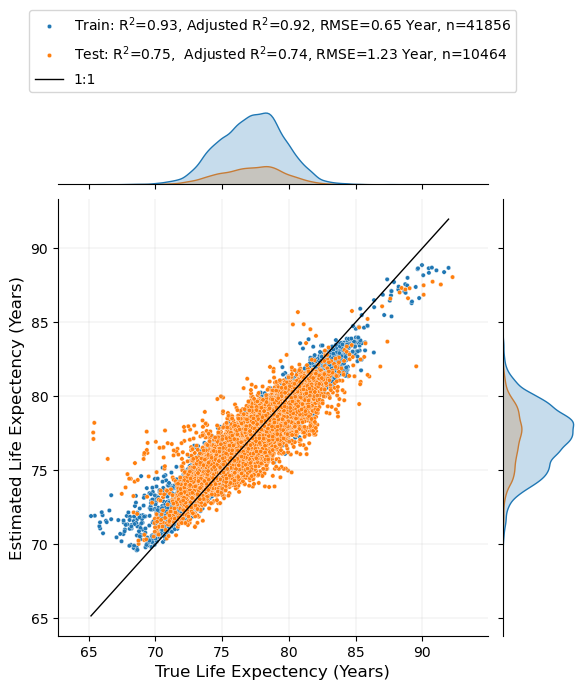

In [31]:
## scatter plot in seaborn

g=sns.jointplot(data=sns_df, x='Actual', y='Estimated', kind="scatter", hue='Label',s=10)
plt.grid(axis='both',linewidth=0.15)

p1 = max(max(train_prediction), max(y_train))
p2 = min(min(train_prediction), min(y_train))

g.ax_joint.plot([p1, p2], [p1, p2], color='k',linewidth=1, label='1:1')

# Customize the legend
handles, labels = g.ax_joint.get_legend_handles_labels()  



g.ax_joint.legend(handles=handles,  
    labels=[ f'Train: R$^2$={corr_train}, Adjusted R$^2$={train_adjusted_r2}, RMSE={rmse_train} Year, n={len(X_train)}', 
        f'Test: R$^2$={corr_test},  Adjusted R$^2$={test_adjusted_r2}, RMSE={rmse_test} Year, n={len(X_test)}','1:1'],
                        title=None)

sns.move_legend(g.ax_joint, "upper center", bbox_to_anchor=(0.5, 1.45))

g.set_axis_labels(r'True Life Expectency (Years)', r'Estimated Life Expectency (Years)',fontsize=12)

plt.show()

In [32]:
df3

,Actual,Estimated,Label
0,75.765442059999998,76.030035678796011,Train
1,77.665309780000001,77.311541416472153,Train
2,76.550869190000000,77.278251548327106,Train
3,74.207778910000002,74.751107206590532,Train
4,75.958222350000000,76.909818621566984,Train
...,...,...,...
41851,78.372938939999997,78.216959030402492,Train
41852,78.728885050000002,78.906769176077077,Train
41853,77.145961290000002,76.513030168779636,Train
41854,79.216647429999995,79.482085174374447,Train


In [33]:
df6

,Actual,Estimated,Label
0,77.935760360000003,78.055326869653030,Test
1,77.376702219999999,76.928391120763493,Test
2,73.825174730000001,74.815136892767242,Test
3,78.091719269999999,78.390404702747176,Test
4,78.501516429999995,78.719673245002198,Test
...,...,...,...
10459,75.378962000000001,77.895090186504262,Test
10460,78.141593940000007,78.998814738469022,Test
10461,73.228819880000003,74.279171129248226,Test
10462,77.121587439999999,76.704818854751920,Test


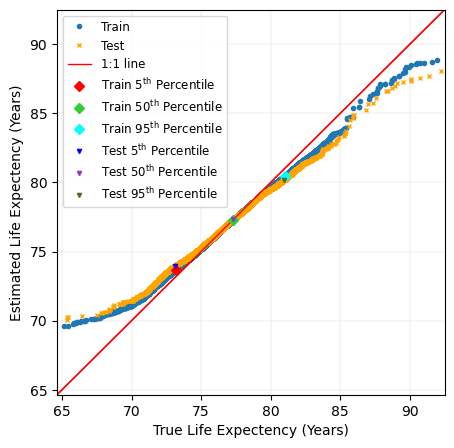

In [34]:
## Lets plot the quantile-quantile plot

fig, ax = plt.subplots(figsize=(5,5))

pp_x = sm.ProbPlot(y_train, fit=False)
pp_y = sm.ProbPlot(train_prediction, fit=False)


qq = pp_y.qqplot(marker='o',markersize=3,other=pp_x,ax=ax, label='Train') ## qq plot for train data
sm.qqline(ax=ax, line='45', fmt='r',linewidth=1)

pp_xx = sm.ProbPlot(y_test, fit=False)
pp_yy = sm.ProbPlot(test_prediction, fit=False)

## overlay qq plot for test data
qqq = pp_yy.qqplot(xlabel='True Life Expectency (Years)',ylabel='Estimated Life Expectency (Years)',
                            marker='x',markersize=3,other=pp_xx,ax=ax,markeredgecolor = 'orange',
                                      markerfacecolor = 'orange', label='Test')

sm.qqline(qq.axes[0], line='45', fmt='r',linewidth=1, label='1:1 line')


## find the percentiles

train_05_actual = df3['Actual'].quantile(0.05)
train_50_actual = df3['Actual'].quantile(0.50)
train_95_actual = df3['Actual'].quantile(0.95)

train_05_estimated = df3['Estimated'].quantile(0.05)
train_50_estimated = df3['Estimated'].quantile(0.50)
train_95_estimated = df3['Estimated'].quantile(0.95)

test_05_actual = df6['Actual'].quantile(0.05)
test_50_actual = df6['Actual'].quantile(0.50)
test_95_actual = df6['Actual'].quantile(0.95)

test_05_estimated = df6['Estimated'].quantile(0.05)
test_50_estimated = df6['Estimated'].quantile(0.50)
test_95_estimated = df6['Estimated'].quantile(0.95)

## plot the percentiles

plt.plot(train_05_actual,train_05_estimated, marker="D",markersize=5,color="red",linestyle ='None',
         label="Train $\\mathrm{5^{th}}$ Percentile")
plt.plot(train_50_actual,train_50_estimated, marker="D",markersize=5,color="limegreen",linestyle ='None',
         label="Train $\\mathrm{50^{th}}$ Percentile")
plt.plot(train_95_actual,train_95_estimated, marker="D",markersize=5,color="Cyan",linestyle ='None',
         label="Train $\\mathrm{95^{th}}$ Percentile")

plt.plot(test_05_actual,test_05_estimated, marker="v",markersize=3,color="blue",linestyle ='None',
         label="Test $\\mathrm{5^{th}}$ Percentile")
plt.plot(test_50_actual,test_50_estimated, marker="v",markersize=3,color="darkorchid",linestyle ='None',
         label="Test $\\mathrm{50^{th}}$ Percentile")
plt.plot(test_95_actual,test_95_estimated, marker="v",markersize=3,color="darkolivegreen",linestyle ='None',
         label="Test $\\mathrm{95^{th}}$ Percentile")


plt.grid(axis='both',linewidth=0.15)
plt.legend(fontsize=8.5)
plt.show()

In [35]:
train_permutation = permutation_importance(final_model, X_train, y_train, 
                                            n_jobs = 6, ## number of cores to run
                                             n_repeats = 10) ## number of times to shuffle, default is 5

In [36]:
mean_val=train_permutation['importances_mean'] ## mean feature importance
std_value=train_permutation['importances_std'] ## standard deviation after shuffling 9 times
feature_names=X_train.columns  ## get features names

mean_importance=sorted(zip(mean_val, feature_names), reverse=True) 
std_importance=sorted(zip(std_value, feature_names), reverse=True)

In [37]:
mean_imp = pd.DataFrame(mean_val, columns=['Mean Weight'])
std_imp = pd.DataFrame(std_value, columns=['Standard Deviation'])
feature_names=list(features.columns.values) ## get list of features as list
feature_df = pd.DataFrame(feature_names, columns=['Feature'])
train_FI = pd.concat([feature_df,mean_imp, std_imp ], axis=1) 
# Sort in descending order
train_FI = train_FI.sort_values(['Mean Weight'], ascending=[False])

In [38]:
train_FI

,Feature,Mean Weight,Standard Deviation
26,Specific humidity,0.222026801558877,0.002295762956128
17,"Leaf area index, low vegetation",0.178373883062538,0.000743460509553
27,Surface pressure,0.172293500719499,0.001205372666146
16,"Leaf area index, high vegetation",0.153475174937109,0.000862038740326
14,Sulphate aerosol mixing ratio,0.118942076514773,0.001350042734788
28,Wet bulb temperature,0.116166364013174,0.001437614672575
5,Formaldehyde,0.111564671527837,0.000825317730430
13,Propane,0.108978064099900,0.001281420432892
3,Dust aerosol (0.03-0.55 µm) mixing ratio,0.106141512533640,0.000889028504077
8,Isoprene,0.051279001572558,0.000276700946534


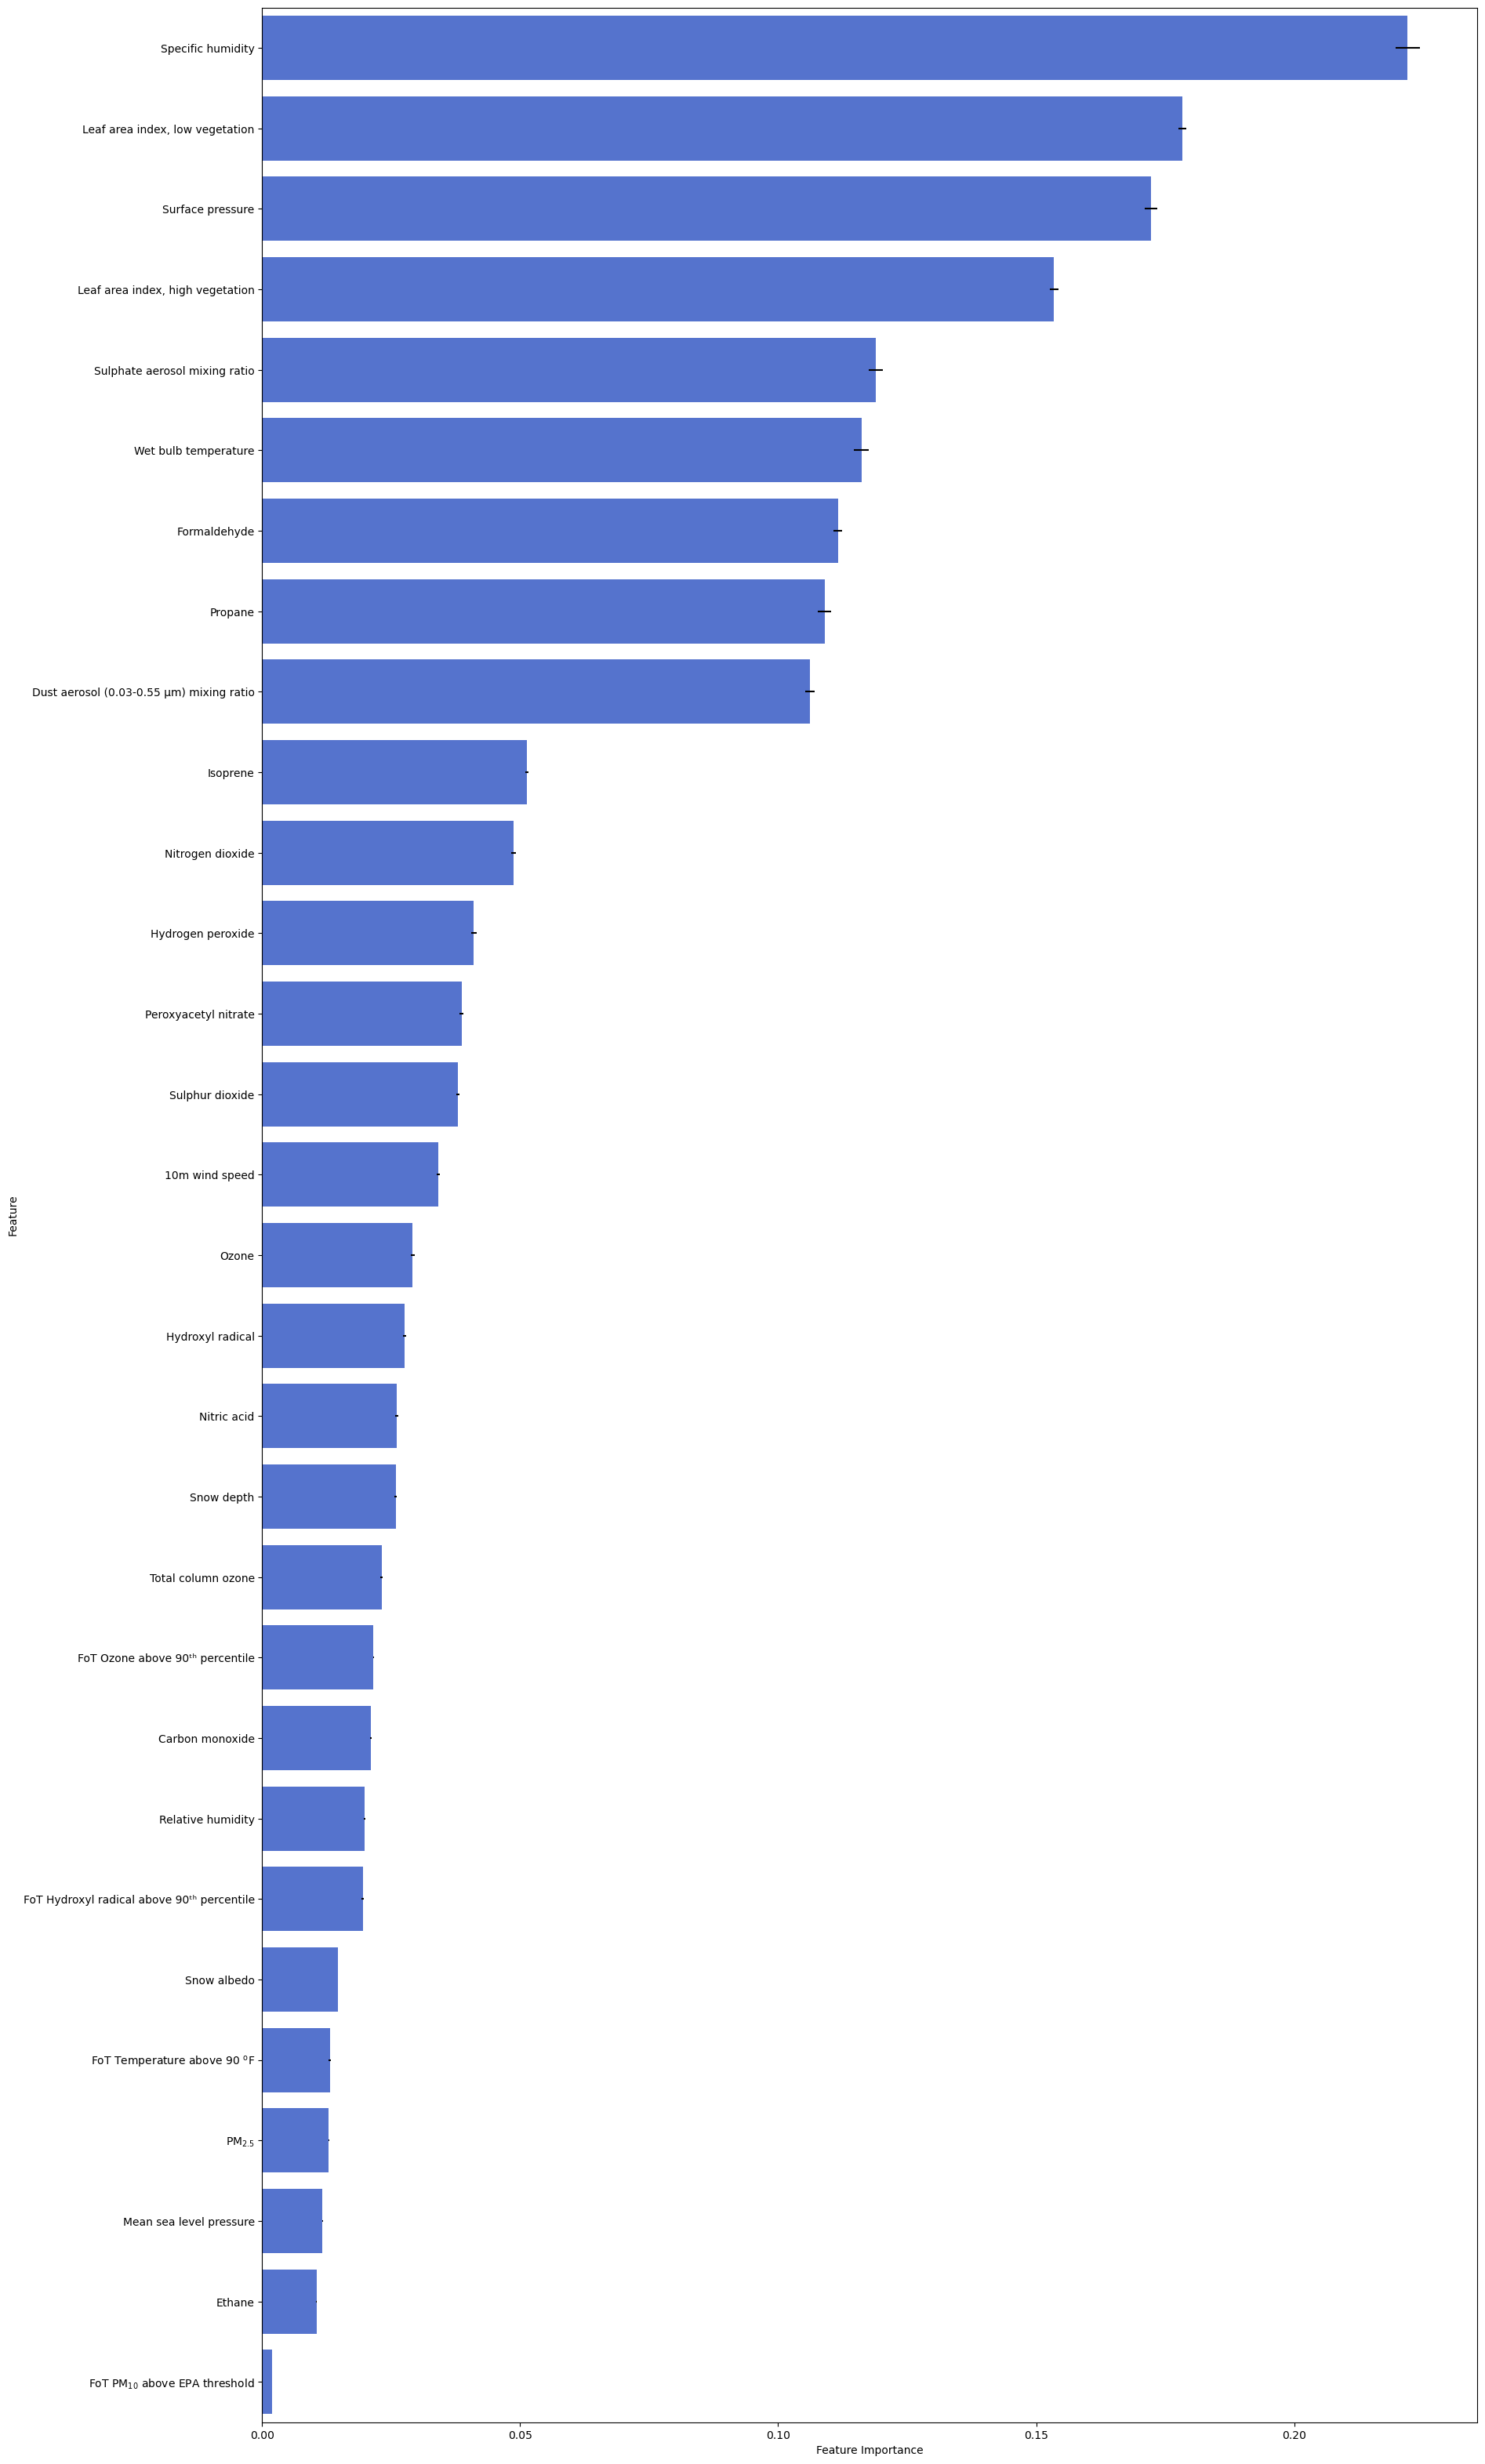

<Figure size 640x480 with 0 Axes>

In [39]:
# Plot with custom error bars
fig, ax = plt.subplots(figsize=(20, 40))

sns.barplot(
    data=train_FI,
    x = "Mean Weight",
    y = "Feature",
    xerr = train_FI["Standard Deviation"],   # explicitly pass the std column
    capsize = 0.2,      # add caps to error bars
    color = "royalblue",
)


plt.xlabel("Feature Importance")
plt.show()
plt.savefig("Feature_Importance_49_train", bbox_inches='tight')

In [40]:
train_FI_15 = train_FI.head(20)

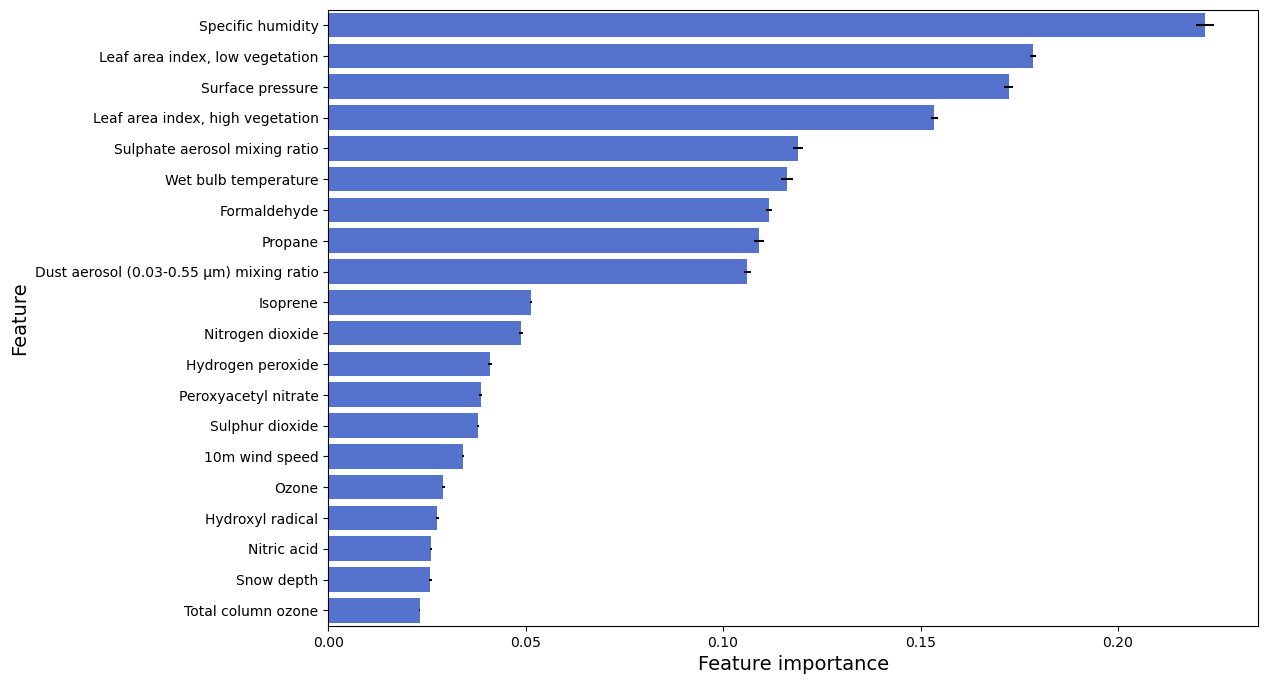

In [41]:
# Plot with custom error bars
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data = train_FI_15,
    x = "Mean Weight",
    y = "Feature",
    xerr = train_FI_15["Standard Deviation"],   # explicitly pass the std column
    capsize = 0.2,      # add caps to error bars
    color = "royalblue",
)

plt.xlabel("Feature importance", fontsize= 14)
plt.ylabel("Feature",fontsize=14)
plt.savefig("Feature_Importance_49_train_reduced", bbox_inches='tight')
plt.show()

In [42]:
test_permutation = permutation_importance(final_model, X_test, y_test, 
                                            n_jobs = 6, ## number of cores to run
                                             n_repeats = 10) ## number of times to shuffle, default is 5

In [43]:
mean_val=test_permutation['importances_mean'] ## mean feature importance
std_value=test_permutation['importances_std'] ## standard deviation after shuffling 10 times
feature_names=X_test.columns  ## get features names

mean_importance=sorted(zip(mean_val, feature_names), reverse=True) 
std_importance=sorted(zip(std_value, feature_names), reverse=True)

In [44]:
mean_imp = pd.DataFrame(mean_val, columns=['Mean Weight'])
std_imp = pd.DataFrame(std_value, columns=['Standard Deviation'])
feature_names=list(features.columns.values) ## get list of features as list
feature_df = pd.DataFrame(feature_names, columns=['Feature'])
test_FI = pd.concat([feature_df,mean_imp, std_imp ], axis=1) 
# Sort in descending order
test_FI = test_FI.sort_values(['Mean Weight'], ascending=[False])

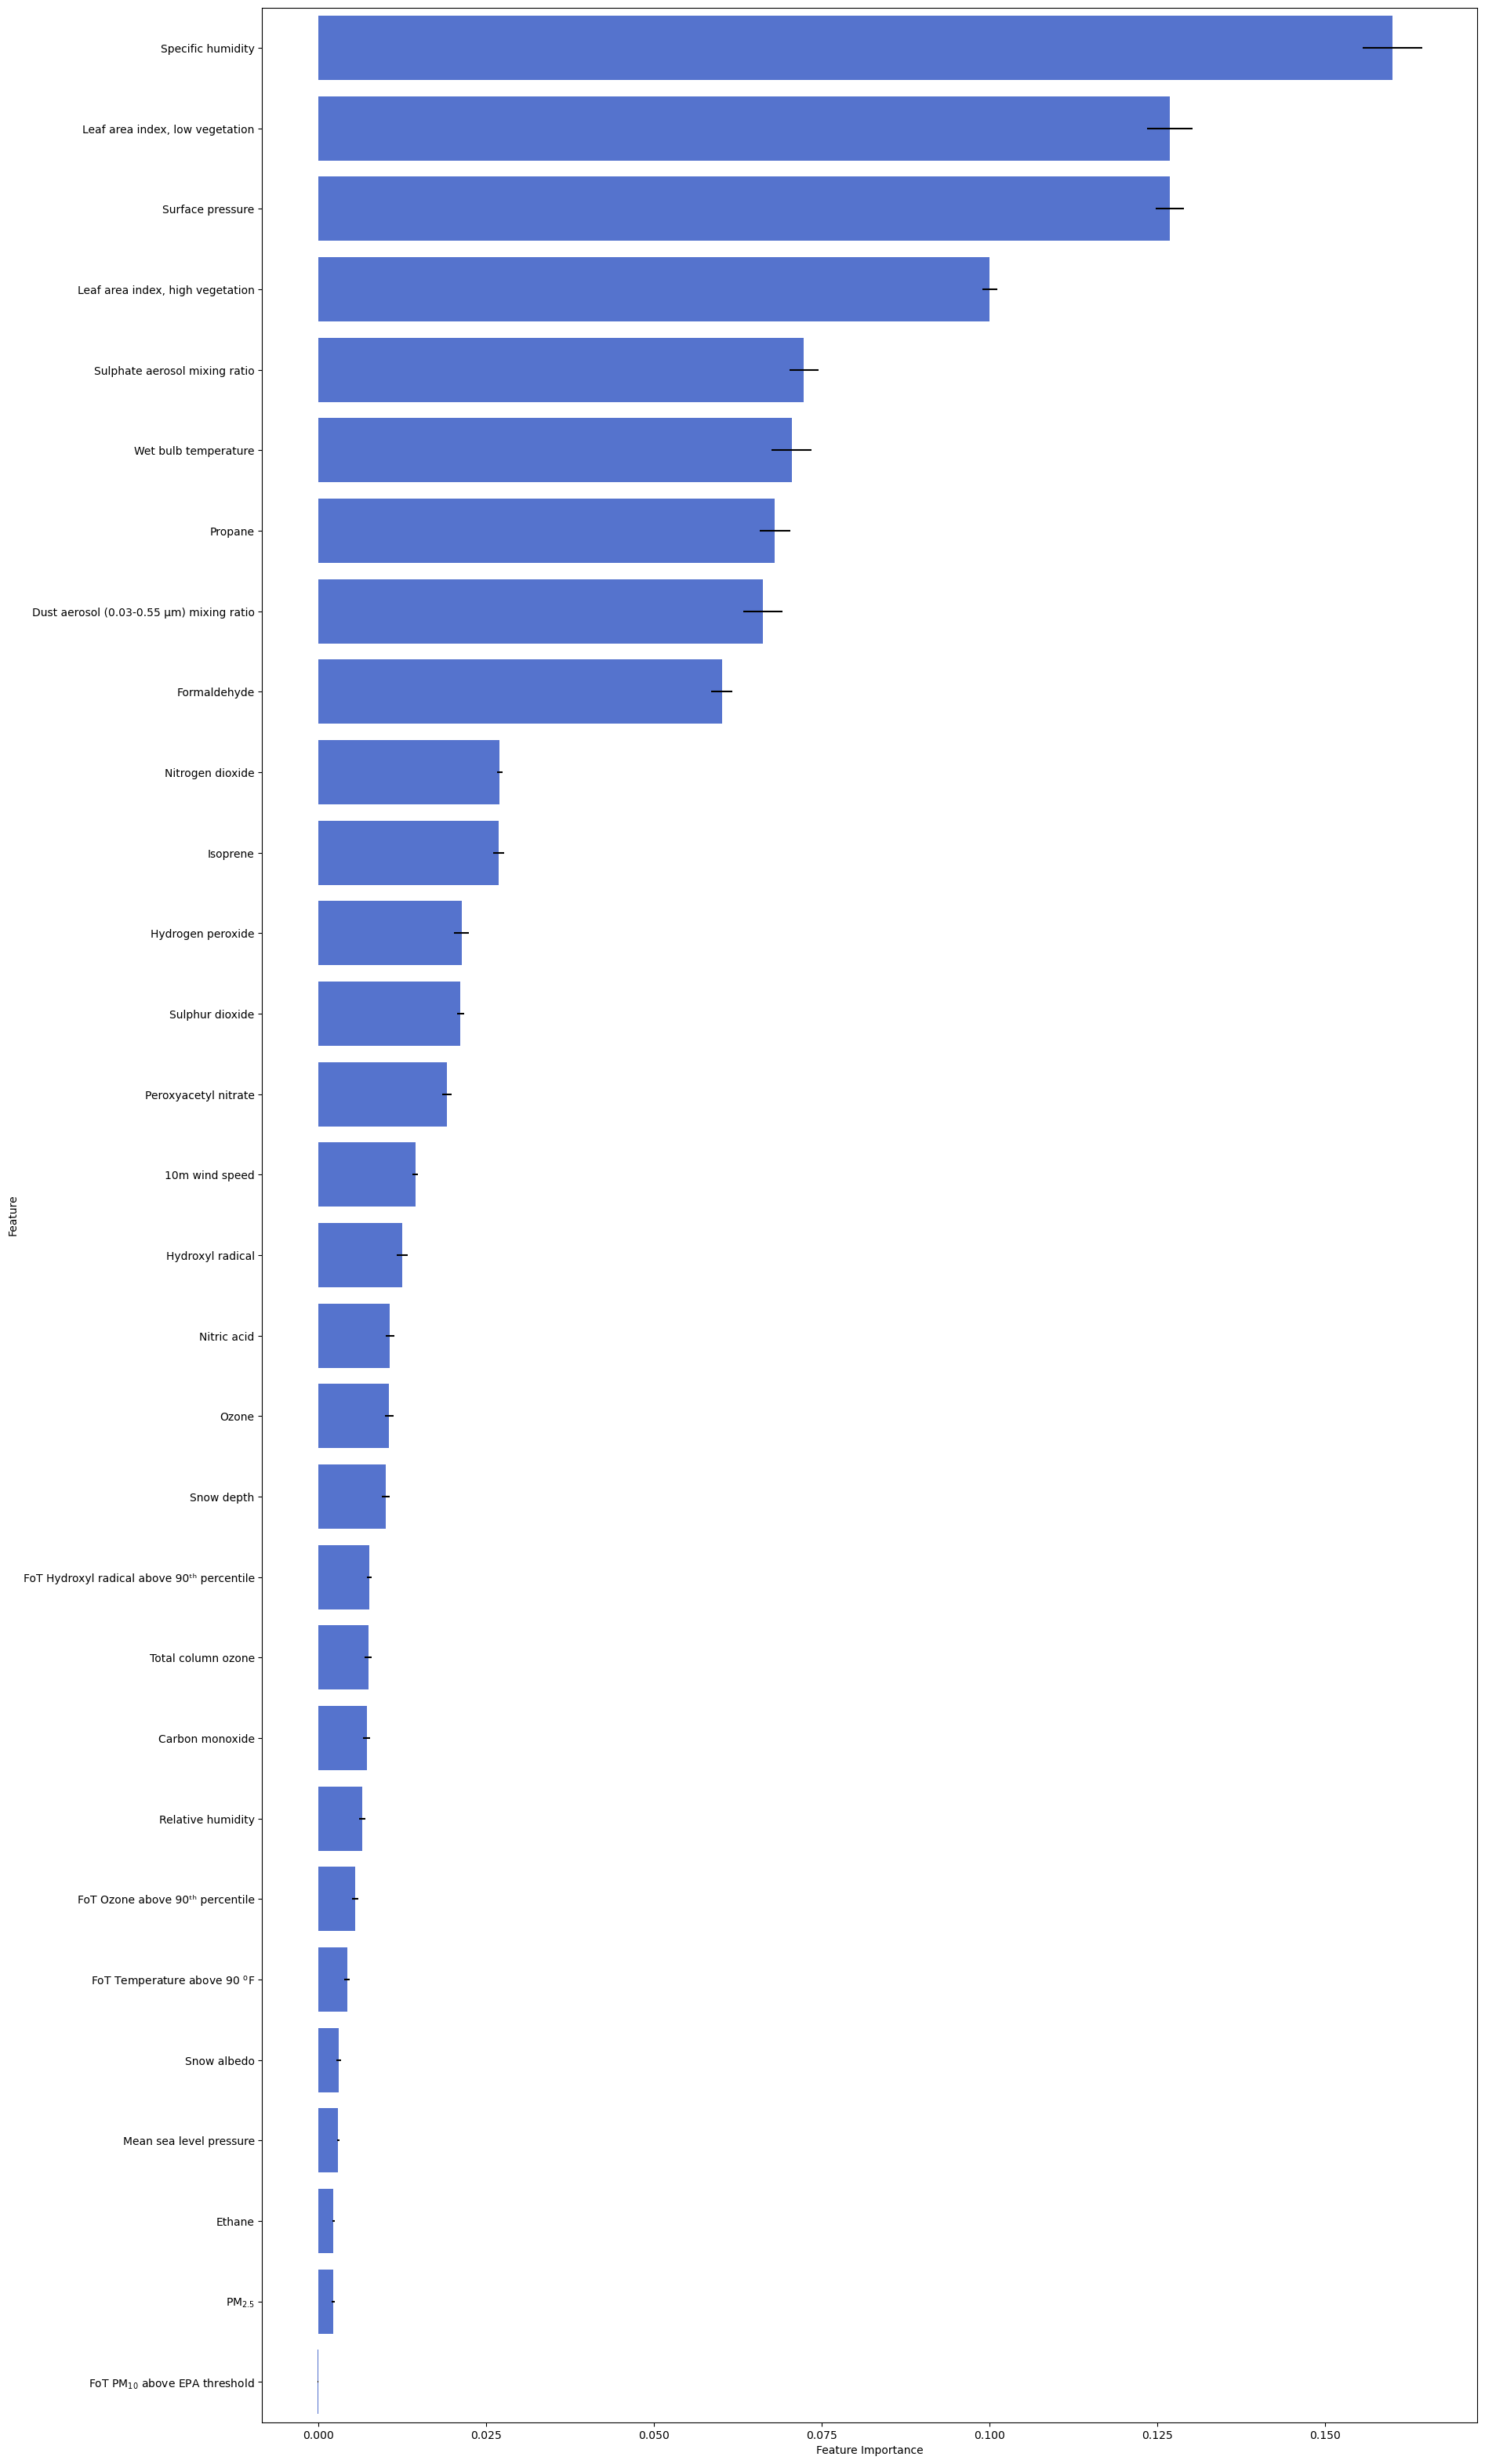

<Figure size 640x480 with 0 Axes>

In [45]:
# Plot with custom error bars
fig, ax = plt.subplots(figsize=(20, 40))

sns.barplot(
    data=test_FI,
    x = "Mean Weight",
    y = "Feature",
    xerr = test_FI["Standard Deviation"],   # explicitly pass the std column
    capsize = 0.2,      # add caps to error bars
    color = "royalblue",
)


plt.xlabel("Feature Importance")
plt.show()
plt.savefig("Feature_Importance_49_test", bbox_inches='tight')

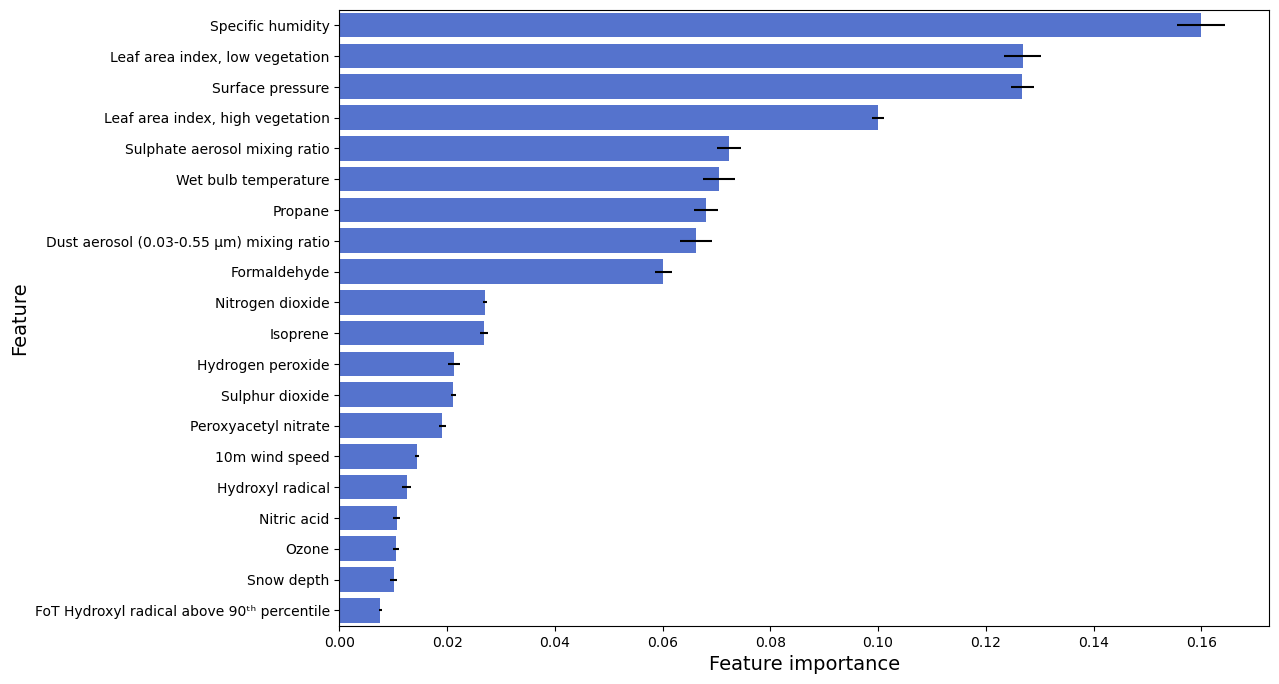

In [46]:
# Plot with custom error bars
test_FI_15 = test_FI.head(20)
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data = test_FI_15,
    x = "Mean Weight",
    y = "Feature",
    xerr = test_FI_15["Standard Deviation"],   # explicitly pass the std column
    capsize = 0.2,      # add caps to error bars
    color = "royalblue",
)

plt.xlabel("Feature importance", fontsize= 14)
plt.ylabel("Feature",fontsize=14)
plt.savefig("Feature_Importance_49_test_reduced", bbox_inches='tight')
plt.show()